In [1]:
pip uninstall -y scikit-learn numpy scipy

Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.4.2 imbalanced-learn==0.14.0 --no-cache-dir --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 186.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 228.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 282.4 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 380.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 371.8 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbal

In [3]:
import os
import tensorflow as tf

# Enable dynamic GPU memory allocation
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU found and configured for dynamic memory allocation.")
    except Exception as e:
        print(f"Error configuring GPU, defaulting to CPU. Error: {e}")
        os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
else:
    print("No GPU found. Using CPU.")
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

2026-01-04 16:09:45.072419: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767542985.266311      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767542985.321357      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU found and configured for dynamic memory allocation.


In [4]:
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input, Bidirectional, LSTM, GRU, Reshape, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from imblearn.keras import BalancedBatchGenerator
from sklearn.metrics import f1_score
import pandas as pd
from tensorflow.keras.models import Model

In [5]:
# --- Section 1: Data Loading and Preprocessing ---
import os
import scipy.io
import numpy as np
import gc

base_path = '/kaggle/input/bciaut-p300/data'
all_eeg_data = []
all_eeg_labels = []
all_subject_ids = []
subjects = sorted([d for d in os.listdir(base_path) if d.startswith('SBJ')])
print(f"Found {len(subjects)} subjects. Starting data loading...")

for subject_id in subjects:
    subject_path = os.path.join(base_path, subject_id)
    sessions = sorted([d for d in os.listdir(subject_path) if d.startswith('S')])
    for session_id in sessions:
        train_data_path = os.path.join(subject_path, session_id, 'Train', 'trainData.mat')
        train_labels_path = os.path.join(subject_path, session_id, 'Train', 'trainTargets.txt')
        try:
            eeg_data_dict = scipy.io.loadmat(train_data_path)
            eeg_data = eeg_data_dict['trainData']
            if eeg_data.size == 0:
                print(f"Empty data in {train_data_path}, skipping.")
                continue
            eeg_labels = np.loadtxt(train_labels_path)
            all_eeg_data.append(eeg_data)
            all_eeg_labels.append(eeg_labels)
            subject_numeric_id = int(subject_id.replace("SBJ", ""))
            all_subject_ids.append(
            np.full(len(eeg_labels), subject_numeric_id)
            )
            del eeg_data, eeg_data_dict  # Free memory
            gc.collect()
        except Exception as e:
            print(f"Error loading {session_id}: {e}")
            continue

if all_eeg_data:
    combined_eeg_data = np.concatenate(all_eeg_data, axis=2)
    combined_eeg_labels = np.concatenate(all_eeg_labels)
    combined_subject_ids = np.concatenate(all_subject_ids)
    print("\nData loading complete!")
    print("Shape of combined EEG data:", combined_eeg_data.shape)
    print("Shape of combined labels:", combined_eeg_labels.shape)
    print("Shape of combined subject ids:", combined_subject_ids.shape)
else:
    print("\nNo data was loaded. Please check the file path.")
    raise ValueError("No data loaded, stopping execution.")

Found 15 subjects. Starting data loading...

Data loading complete!
Shape of combined EEG data: (8, 350, 168000)
Shape of combined labels: (168000,)
Shape of combined subject ids: (168000,)


In [6]:
X = np.transpose(combined_eeg_data, (2, 1, 0))
y = combined_eeg_labels.astype(int)
subject_ids = combined_subject_ids

In [7]:
unique_subjects = np.unique(subject_ids)

In [8]:
import numpy as np
import scipy.signal as sg
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import gc

In [9]:
SFREQ = 250                     # Hz
WINDOW_START = -200             # in ms (dataset reference only)
CROP_START_MS = 200             # desired window start (200ms)
CROP_END_MS   = 600             # desired window end (600ms)

In [10]:
# dataset samples: -200 ms → 1200 ms = 1400ms total
# 1 ms = SFREQ / 1000 samples

samples_per_ms = SFREQ / 1000
crop_start_idx = int((CROP_START_MS - WINDOW_START) * samples_per_ms)
crop_end_idx   = int((CROP_END_MS   - WINDOW_START) * samples_per_ms)

print("Cropping indices:", crop_start_idx, crop_end_idx)

Cropping indices: 100 200


In [11]:
print("Raw X:", X.shape)

X = X[:, crop_start_idx : crop_end_idx, :]
print("After cropping:", X.shape)

Raw X: (168000, 350, 8)
After cropping: (168000, 100, 8)


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization,
    MaxPooling1D, Flatten, Dense, Dropout
)
from tensorflow.keras.optimizers import Adam


def build_cnn(input_shape, num_classes):

    model = Sequential([
        Input(shape=input_shape),

        Conv1D(32, kernel_size=5, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300')
        ]
    )

    return model


In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_cnn(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")



Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120


I0000 00:00:1767438225.898821      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767438225.899603      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1767438232.055362     121 service.cc:148] XLA service 0x79fdfc0123f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767438232.056136     121 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767438232.056161     121 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767438232.509365     121 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1767438235.856618     121 device_compiler.h:188] Compiled clust

Fold 1 | F1 P300: 0.326 | F1 Non-P300: 0.758

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.304 | F1 Non-P300: 0.763

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.317 | F1 Non-P300: 0.737

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.334 | F1 Non-P300: 0.784

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.326 | F1 Non-P300: 0.772

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.449 | F1 Non-P300: 0.851

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.472 | F1 Non-P300: 0.854

Subject 2 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 11

In [15]:
import pandas as pd
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

    subject   f1_p300  f1_nonp300
0         1  0.321285    0.762690
1         2  0.458220    0.847958
2         3  0.309550    0.712656
3         4  0.356809    0.734981
4         5  0.395359    0.821750
5         6  0.434775    0.839528
6         7  0.383408    0.816422
7         8  0.454397    0.851812
8         9  0.312995    0.761527
9        10  0.511765    0.881686
10       11  0.465118    0.859357
11       12  0.338662    0.782568
12       13  0.347222    0.777765
13       14  0.312617    0.744787
14       15  0.409590    0.823131

Mean Subject-wise F1 P300     : 0.38745146470385833
Mean Subject-wise F1 Non-P300 : 0.8012411068912851


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense
)
from tensorflow.keras.optimizers import Adam


def build_bilstm_model(input_shape, num_classes):
    """
    Bi-LSTM model for P300 detection
    input_shape: (time, channels)
    num_classes: 2 (Non-P300, P300)
    """

    input_tensor = Input(shape=input_shape)  # (time, channels)

    # -------------------------
    # CNN front-end
    # -------------------------
    x = Conv1D(filters=32, kernel_size=5, padding='same',
               activation='relu')(input_tensor)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.4)(x)

    # -------------------------
    # Bi-LSTM stack
    # -------------------------
    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = Dropout(0.4)(x)

    x = Bidirectional(LSTM(16))(x)
    x = Dropout(0.4)(x)

    # -------------------------
    # Classifier
    # -------------------------
    x = Dense(64, activation='relu')(x)
    output_tensor = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output_tensor)

    # -------------------------
    # Compile
    # -------------------------
    model.compile(
        optimizer=Adam(learning_rate=1e-4, clipvalue=1.0),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300')
        ]
    )

    return model


In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_bilstm_model(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")



Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.305 | F1 Non-P300: 0.762

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.287 | F1 Non-P300: 0.760

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.310 | F1 Non-P300: 0.756

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.316 | F1 Non-P300: 0.817

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.279 | F1 Non-P300: 0.670

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.389 | F1 Non-P300: 0.834

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non

In [17]:
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

    subject   f1_p300  f1_nonp300
0         1  0.299378    0.753043
1         2  0.379577    0.796829
2         3  0.259868    0.712910
3         4  0.319258    0.756447
4         5  0.316500    0.783455
5         6  0.362681    0.755191
6         7  0.281929    0.724180
7         8  0.378497    0.819487
8         9  0.261200    0.741182
9        10  0.513626    0.893148
10       11  0.328460    0.769525
11       12  0.303034    0.703168
12       13  0.277682    0.744240
13       14  0.264032    0.716175
14       15  0.304292    0.752693

Mean Subject-wise F1 P300     : 0.32333414887568346
Mean Subject-wise F1 Non-P300 : 0.7614449081077562


In [18]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    Dense, Multiply, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


def build_TGT_MHAG_model(input_shape, num_classes):
    """
    TGT-MHAG model builder
    input_shape: (time, channels)
    """

    inp = Input(shape=input_shape)

    # -----------------------------
    # CNN Front-end
    # -----------------------------
    x = Conv1D(32, kernel_size=5, padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)

    # -----------------------------
    # Temporal Gated Attention
    # -----------------------------
    attn = Dense(32, activation='sigmoid')(x)
    x = Multiply()([x, attn])

    # -----------------------------
    # Feature Aggregation
    # -----------------------------
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = GlobalAveragePooling1D()(x)

    # -----------------------------
    # Classifier
    # -----------------------------
    x = Dense(64, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300')
        ]
    )

    return model

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_TGT_MHAG_model(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")


Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.243 | F1 Non-P300: 0.732

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.232 | F1 Non-P300: 0.674

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.231 | F1 Non-P300: 0.744

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.195 | F1 Non-P300: 0.779

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.237 | F1 Non-P300: 0.652

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.276 | F1 Non-P300: 0.655

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non

In [20]:
import pandas as pd
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

    subject   f1_p300  f1_nonp300
0         1  0.227317    0.716070
1         2  0.283074    0.729645
2         3  0.228745    0.665061
3         4  0.269492    0.707019
4         5  0.279959    0.770687
5         6  0.289572    0.672188
6         7  0.261451    0.752223
7         8  0.332486    0.795185
8         9  0.246276    0.686859
9        10  0.364418    0.816468
10       11  0.313425    0.777667
11       12  0.237808    0.675180
12       13  0.233819    0.682970
13       14  0.221402    0.669102
14       15  0.266024    0.734177

Mean Subject-wise F1 P300     : 0.27035117092666494
Mean Subject-wise F1 Non-P300 : 0.723366691040603


In [12]:
def plot_confusion_matrix(y_true, y_pred, model_name, labels=['Non-P300', 'P300'], title_suffix=''):
    """
    Generates and displays a confusion matrix plot.
    
    y_true: true labels
    y_pred: predicted labels (can be probabilities or class indices)
    """
    # If y_pred are probabilities, convert to class indices
    if y_pred.ndim > 1 and y_pred.shape[1] > 1:
        y_pred = y_pred.argmax(axis=1)
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f'Confusion Matrix for {model_name}{title_suffix}')
    plt.show()

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

def build_TGTMHAG_Conv2D(input_shape, num_classes=2):
    """
    TGT-MHAG using Conv2D
    Input shape: (T, C, 1)
    """

    inp = Input(shape=input_shape)

    # -----------------------------
    # Temporal Convolution
    # -----------------------------
    x = Conv2D(32, (25, 1), padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)

    # -----------------------------
    # Temporal Gated Attention
    # -----------------------------
    gate = Conv2D(32, (1, 1), activation='sigmoid')(x)
    x = Multiply()([x, gate])

    # -----------------------------
    # Spatial Convolution
    # -----------------------------
    x = Conv2D(64, (1, input_shape[1]), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x)

    # -----------------------------
    # Reshape for MH Attention
    # -----------------------------
    t, c = x.shape[1], x.shape[-1]
    x = Reshape((t, c))(x)

    # -----------------------------
    # Multi-Head Attention
    # -----------------------------
    x = MultiHeadAttention(num_heads=4, key_dim=c // 4)(x, x)
    x = LayerNormalization()(x)

    # -----------------------------
    # Classifier
    # -----------------------------
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out, name="TGT_MHAG_Conv2D")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300')
        ]
    )

    return model


In [14]:
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc, numpy as np, tensorflow as tf

all_y_true, all_y_pred = [], []
loso_results = []

unique_subjects = np.unique(subject_ids)

print(f"Starting LOSO-CV with {len(unique_subjects)} subjects")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\nLOSO Fold {fold} | Test Subject {test_subject}")

    # -------- SPLIT --------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -------- DOWNSAMPLE TRAIN ONLY --------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx)

    X_train, y_train = X_train[idx], y_train[idx]
    X_train = X_train[..., np.newaxis]
    X_test  = X_test[..., np.newaxis]

    y_train_cat = to_categorical(y_train, 2)

    # -------- BUILD MODEL --------
    model = build_TGTMHAG_Conv2D(
        input_shape=X_train.shape[1:],
        num_classes=2
    )

    # -------- TRAIN --------
    model.fit(
        X_train, y_train_cat,
        epochs=20,
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -------- TEST --------
    probs = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs >= 0.5).astype(int)

    # -------- METRICS --------
    f1_p300     = f1_score(y_test, y_pred, pos_label=1)
    f1_nonp300  = f1_score(y_test, y_pred, pos_label=0)

    print(f"F1 P300: {f1_p300:.3f}, F1 Non-P300: {f1_nonp300:.3f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    del model
    tf.keras.backend.clear_session()
    gc.collect()


Starting LOSO-CV with 15 subjects

LOSO Fold 1 | Test Subject 1


I0000 00:00:1767510301.390699      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767510301.391299      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1767510308.768327     124 service.cc:148] XLA service 0x7f2564017f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767510308.768860     124 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767510308.768878     124 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767510309.315460     124 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1767510313.520593     124 device_compiler.h:188] Compiled clust

F1 P300: 0.231, F1 Non-P300: 0.787

LOSO Fold 2 | Test Subject 2
F1 P300: 0.316, F1 Non-P300: 0.896

LOSO Fold 3 | Test Subject 3
F1 P300: 0.267, F1 Non-P300: 0.753

LOSO Fold 4 | Test Subject 4
F1 P300: 0.290, F1 Non-P300: 0.738

LOSO Fold 5 | Test Subject 5
F1 P300: 0.284, F1 Non-P300: 0.713

LOSO Fold 6 | Test Subject 6
F1 P300: 0.251, F1 Non-P300: 0.717

LOSO Fold 7 | Test Subject 7
F1 P300: 0.356, F1 Non-P300: 0.855

LOSO Fold 8 | Test Subject 8
F1 P300: 0.449, F1 Non-P300: 0.932

LOSO Fold 9 | Test Subject 9
F1 P300: 0.281, F1 Non-P300: 0.716

LOSO Fold 10 | Test Subject 10
F1 P300: 0.355, F1 Non-P300: 0.832

LOSO Fold 11 | Test Subject 11
F1 P300: 0.268, F1 Non-P300: 0.592

LOSO Fold 12 | Test Subject 12
F1 P300: 0.283, F1 Non-P300: 0.763

LOSO Fold 13 | Test Subject 13
F1 P300: 0.275, F1 Non-P300: 0.715

LOSO Fold 14 | Test Subject 14
F1 P300: 0.255, F1 Non-P300: 0.773

LOSO Fold 15 | Test Subject 15
F1 P300: 0.282, F1 Non-P300: 0.757


In [15]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())


========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.230738    0.787188
1         2  0.315754    0.895895
2         3  0.266761    0.753371
3         4  0.289596    0.737961
4         5  0.283843    0.712785
5         6  0.251425    0.717264
6         7  0.355577    0.855362
7         8  0.449311    0.931875
8         9  0.281304    0.715719
9        10  0.354978    0.832396
10       11  0.267681    0.591810
11       12  0.283453    0.763420
12       13  0.275360    0.715254
13       14  0.255311    0.773450
14       15  0.282038    0.756501

Mean F1 P300     : 0.296208638872903
Mean F1 Non-P300 : 0.7693501395471841



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.91      0.67      0.78    147000
        P300       0.19      0.55      0.29     21000

    accuracy                           0.66    168000
   macro avg       0.55      0.61      0.53    168000
weighted avg       0.82      0.66      0.71    168000



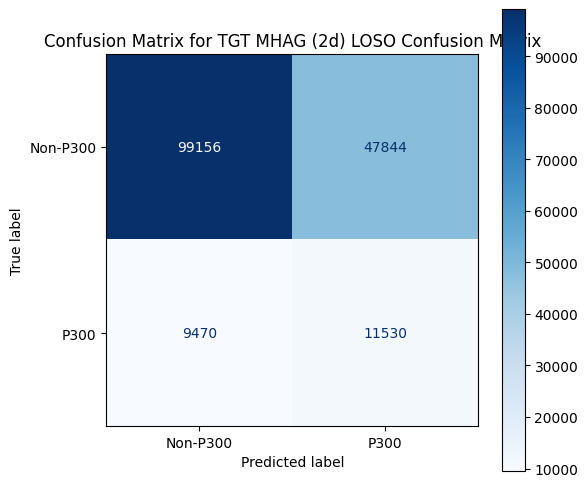

In [16]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "TGT MHAG (2d) LOSO Confusion Matrix"
)

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # SHAPE FIX (ONLY if Conv2D)
        # -----------------------------
        if len(X_train.shape) == 3:
            X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
            X_test  = X_test[..., np.newaxis]

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_TGTMHAG_Conv2D(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")


Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.237 | F1 Non-P300: 0.671

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.219 | F1 Non-P300: 0.815

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.253 | F1 Non-P300: 0.672

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.228 | F1 Non-P300: 0.625

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.249 | F1 Non-P300: 0.636

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.346 | F1 Non-P300: 0.774

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non

In [18]:
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

    subject   f1_p300  f1_nonp300
0         1  0.237189    0.683610
1         2  0.353510    0.776167
2         3  0.226817    0.702286
3         4  0.319579    0.835337
4         5  0.306515    0.763237
5         6  0.324208    0.769551
6         7  0.289455    0.772750
7         8  0.408310    0.846391
8         9  0.241859    0.715913
9        10  0.419417    0.855455
10       11  0.324855    0.774825
11       12  0.266888    0.710462
12       13  0.265237    0.669714
13       14  0.241429    0.676829
14       15  0.357241    0.809583

Mean Subject-wise F1 P300     : 0.3055005874525883
Mean Subject-wise F1 Non-P300 : 0.7574740089944371


In [16]:
from tensorflow.keras import backend as K

def channel_attention(x, ratio=8):
    ch = x.shape[-1]
    avg = GlobalAveragePooling1D()(x)
    maxp = GlobalMaxPooling1D()(x)
    shared = Dense(ch // ratio, activation='relu')
    avg = Dense(ch)(shared(avg))
    maxp = Dense(ch)(shared(maxp))
    attn = Activation('sigmoid')(avg + maxp)
    return Multiply()([x, attn])

def spatial_attention(x):
    avg = Lambda(lambda z: K.mean(z, axis=-1, keepdims=True))(x)
    maxp = Lambda(lambda z: K.max(z, axis=-1, keepdims=True))(x)
    concat = Concatenate()([avg, maxp])
    attn = Conv1D(1, 7, padding='same', activation='sigmoid')(concat)
    return Multiply()([x, attn])

def cbam_block(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

In [14]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout, Dense,
    GlobalAveragePooling1D, GlobalMaxPooling1D,
    Multiply, Add, Activation, Reshape, Concatenate,
    Bidirectional, LSTM, Lambda
)
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


def build_CBAM_BiLSTM_model(input_shape, num_classes):
    """
    CBAM + BiLSTM model for P300 classification
    input_shape: (time, channels)
    """

    inp = Input(shape=input_shape)

    # CNN + CBAM
    x = Conv1D(32, 5, padding='same', activation='relu')(inp)
    x = cbam_block(x)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.4)(x)

    # BiLSTM stack
    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = Dropout(0.4)(x)
    x = Bidirectional(LSTM(16))(x)

    # Classifier
    x = Dense(64, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300')
        ]
    )

    return model

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_CBAM_BiLSTM_model(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")


Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120


I0000 00:00:1767456353.555476     126 cuda_dnn.cc:529] Loaded cuDNN version 90300


Fold 1 | F1 P300: 0.330 | F1 Non-P300: 0.785

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.331 | F1 Non-P300: 0.838

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.312 | F1 Non-P300: 0.781

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.334 | F1 Non-P300: 0.749

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.271 | F1 Non-P300: 0.721

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.505 | F1 Non-P300: 0.880

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.442 | F1 Non-P300: 0.853

Subject 2 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 11

In [18]:
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

    subject   f1_p300  f1_nonp300
0         1  0.315784    0.774956
1         2  0.469691    0.864126
2         3  0.283689    0.718206
3         4  0.361375    0.797947
4         5  0.345525    0.803018
5         6  0.365136    0.779887
6         7  0.340475    0.781889
7         8  0.444589    0.853253
8         9  0.281869    0.764893
9        10  0.542779    0.902400
10       11  0.412569    0.845229
11       12  0.358671    0.796009
12       13  0.280120    0.741336
13       14  0.265680    0.673444
14       15  0.377693    0.843769

Mean Subject-wise F1 P300     : 0.36304304642242524
Mean Subject-wise F1 Non-P300 : 0.7960240847774569


In [19]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, DepthwiseConv1D, BatchNormalization,
    Activation, Dropout, GlobalAveragePooling1D,
    Dense, Multiply, Add, AveragePooling1D,
    Bidirectional, LSTM
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense, Activation, Multiply, Lambda

def CBAM_Channel_Attention(x, ratio=8):
    channel = x.shape[-1]

    # Global Average Pooling
    avg_out = GlobalAveragePooling1D()(x)
    
    # MLP
    avg_out = Dense(channel // ratio, activation='relu')(avg_out)
    avg_out = Dense(channel)(avg_out)
    
    # Sigmoid + expand dims
    scale = Activation('sigmoid')(avg_out)
    scale = Lambda(lambda s: tf.expand_dims(s, axis=1))(scale)  

    # Scale
    return Multiply()([x, scale])
def MultiScale_Temporal_Block(x, filters):
    conv3 = Conv1D(filters, 3, padding='same', activation='elu')(x)
    conv5 = Conv1D(filters, 5, padding='same', activation='elu')(x)
    conv7 = Conv1D(filters, 7, padding='same', activation='elu')(x)

    x = Add()([conv3, conv5, conv7])
    x = BatchNormalization()(x)
    return x


In [20]:
def build_TGTMHAG_CBAM_BiLSTM(input_shape=(100, 8), num_classes=2):
    inputs = Input(shape=input_shape)

    # ──────────────────────────────
    # Temporal Feature Extraction
    # ──────────────────────────────
    x = Conv1D(32, kernel_size=15, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = Dropout(0.3)(x)

    # ──────────────────────────────
    # Multi-Scale Temporal Learning
    # ──────────────────────────────
    x = MultiScale_Temporal_Block(x, filters=32)

    # ──────────────────────────────
    # Channel Attention (CBAM)
    # ──────────────────────────────
    x = CBAM_Channel_Attention(x, ratio=8)

    # ──────────────────────────────
    # Depthwise Channel Mixing
    # ──────────────────────────────
    x = DepthwiseConv1D(kernel_size=1, depth_multiplier=2)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    # ──────────────────────────────
    # Temporal Downsampling
    # ──────────────────────────────
    x = AveragePooling1D(pool_size=4)(x)
    x = Dropout(0.3)(x)

    # ──────────────────────────────
    # BiLSTM (Latency Handling)
    # ──────────────────────────────
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(32))(x)
    x = Dropout(0.3)(x)

    # ──────────────────────────────
    # Classifier
    # ──────────────────────────────
    x = Dense(64, activation='elu')(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=[
            tf.metrics.AUC(name='auc'),
        tf.metrics.Recall(class_id=1, name='recall_p300'),
        tf.metrics.Precision(class_id=1, name='precision_p300'),
        tf.metrics.Recall(class_id=0, name='recall_nonp300'),
        tf.metrics.Precision(class_id=0, name='precision_nonp300')
        ]
    )

    return model


In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_TGTMHAG_CBAM_BiLSTM(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")


Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.352 | F1 Non-P300: 0.775

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.340 | F1 Non-P300: 0.742

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.364 | F1 Non-P300: 0.794

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.373 | F1 Non-P300: 0.791

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.362 | F1 Non-P300: 0.790

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.535 | F1 Non-P300: 0.881

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non

In [23]:
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

    subject   f1_p300  f1_nonp300
0         1  0.358179    0.778514
1         2  0.519858    0.873211
2         3  0.365437    0.835708
3         4  0.449095    0.862290
4         5  0.448480    0.857304
5         6  0.451633    0.832187
6         7  0.465933    0.872986
7         8  0.611578    0.923927
8         9  0.347084    0.797210
9        10  0.630113    0.928883
10       11  0.556243    0.906182
11       12  0.392566    0.804120
12       13  0.352016    0.777293
13       14  0.317669    0.731614
14       15  0.535248    0.898433

Mean Subject-wise F1 P300     : 0.45340888523487716
Mean Subject-wise F1 Non-P300 : 0.8453241492615953


In [17]:
def channel_attention_2d(x, ratio=8):
    ch = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    shared_dense_1 = Dense(ch // ratio, activation='relu')
    shared_dense_2 = Dense(ch)

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    attn = Add()([avg_out, max_out])
    attn = Activation('sigmoid')(attn)

    attn = Reshape((1, 1, ch))(attn)
    return Multiply()([x, attn])
def spatial_attention_2d(x):
    avg_pool = Lambda(lambda z: tf.reduce_mean(z, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda z: tf.reduce_max(z, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    attn = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    return Multiply()([x, attn])
def cbam_block_2d(x):
    x = channel_attention_2d(x)
    x = spatial_attention_2d(x)
    return x

In [18]:
def build_TGTMHAG_Conv2D_CBAM_BiLSTM(input_shape, num_classes=2):
    """
    TGT-MHAG + CBAM-2D + BiLSTM
    Input: (T, C, 1)
    """

    inp = Input(shape=input_shape)

    # -----------------------------
    # Temporal Conv
    # -----------------------------
    x = Conv2D(32, (25, 1), padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)

    # -----------------------------
    # Temporal Gated Attention
    # -----------------------------
    gate = Conv2D(32, (1, 1), activation='sigmoid')(x)
    x = Multiply()([x, gate])

    # -----------------------------
    # Spatial Conv
    # -----------------------------
    x = Conv2D(64, (1, input_shape[1]), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x)

    # -----------------------------
    # CBAM (2D)
    # -----------------------------
    x = cbam_block_2d(x)

    # -----------------------------
    # Reshape → BiLSTM
    # -----------------------------
    x = Lambda(lambda z: tf.squeeze(z, axis=2))(x)  # (B, T, F)

    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = Dropout(0.4)(x)
    x = Bidirectional(LSTM(16))(x)

    # -----------------------------
    # Classifier
    # -----------------------------
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out, name="TGT_MHAG_CBAM_BiLSTM")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300')
        ]
    )

    return model


In [19]:
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc, numpy as np, tensorflow as tf
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Dense,
    Reshape,
    Multiply,
    Add,
    Activation,
    Lambda,
    Concatenate
)

all_y_true, all_y_pred = [], []
loso_results = []

unique_subjects = np.unique(subject_ids)

print(f"Starting LOSO-CV with {len(unique_subjects)} subjects")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\nLOSO Fold {fold} | Test Subject {test_subject}")

    # -------- SPLIT --------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -------- DOWNSAMPLE TRAIN ONLY --------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx)

    X_train, y_train = X_train[idx], y_train[idx]
    X_train = X_train[..., np.newaxis]
    X_test  = X_test[..., np.newaxis]

    y_train_cat = to_categorical(y_train, 2)

    # -------- BUILD MODEL --------
    model = build_TGTMHAG_Conv2D_CBAM_BiLSTM(
        input_shape=X_train.shape[1:],
        num_classes=2
    )

    # -------- TRAIN --------
    model.fit(
        X_train, y_train_cat,
        epochs=20,
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -------- TEST --------
    probs = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs >= 0.5).astype(int)

    # -------- METRICS --------
    f1_p300     = f1_score(y_test, y_pred, pos_label=1)
    f1_nonp300  = f1_score(y_test, y_pred, pos_label=0)

    print(f"F1 P300: {f1_p300:.3f}, F1 Non-P300: {f1_nonp300:.3f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    del model
    tf.keras.backend.clear_session()
    gc.collect()


Starting LOSO-CV with 15 subjects

LOSO Fold 1 | Test Subject 1
F1 P300: 0.274, F1 Non-P300: 0.823

LOSO Fold 2 | Test Subject 2
F1 P300: 0.423, F1 Non-P300: 0.871

LOSO Fold 3 | Test Subject 3
F1 P300: 0.290, F1 Non-P300: 0.778

LOSO Fold 4 | Test Subject 4
F1 P300: 0.344, F1 Non-P300: 0.797

LOSO Fold 5 | Test Subject 5
F1 P300: 0.332, F1 Non-P300: 0.736

LOSO Fold 6 | Test Subject 6
F1 P300: 0.292, F1 Non-P300: 0.725

LOSO Fold 7 | Test Subject 7
F1 P300: 0.465, F1 Non-P300: 0.882

LOSO Fold 8 | Test Subject 8
F1 P300: 0.576, F1 Non-P300: 0.917

LOSO Fold 9 | Test Subject 9
F1 P300: 0.337, F1 Non-P300: 0.831

LOSO Fold 10 | Test Subject 10
F1 P300: 0.485, F1 Non-P300: 0.881

LOSO Fold 11 | Test Subject 11
F1 P300: 0.329, F1 Non-P300: 0.780

LOSO Fold 12 | Test Subject 12
F1 P300: 0.333, F1 Non-P300: 0.815

LOSO Fold 13 | Test Subject 13
F1 P300: 0.344, F1 Non-P300: 0.804

LOSO Fold 14 | Test Subject 14
F1 P300: 0.291, F1 Non-P300: 0.751

LOSO Fold 15 | Test Subject 15
F1 P300: 0.346

In [20]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())


========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.274179    0.823379
1         2  0.422824    0.870649
2         3  0.289572    0.778064
3         4  0.343720    0.796843
4         5  0.331650    0.736272
5         6  0.291959    0.724895
6         7  0.464876    0.881644
7         8  0.576096    0.916858
8         9  0.337074    0.831252
9        10  0.484877    0.881160
10       11  0.328940    0.779550
11       12  0.333059    0.815300
12       13  0.344466    0.804290
13       14  0.291402    0.750860
14       15  0.346197    0.795452

Mean F1 P300     : 0.36405944401553775
Mean F1 Non-P300 : 0.8124312326896381



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.93      0.72      0.81    147000
        P300       0.25      0.63      0.35     21000

    accuracy                           0.71    168000
   macro avg       0.59      0.68      0.58    168000
weighted avg       0.85      0.71      0.76    168000



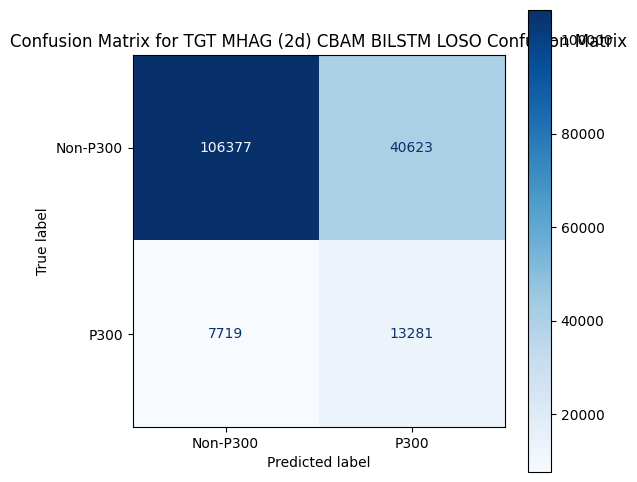

In [21]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "TGT MHAG (2d) CBAM BILSTM LOSO Confusion Matrix"
)

In [34]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Dense,
    Reshape,
    Multiply,
    Add,
    Activation,
    Lambda,
    Concatenate
)

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # SHAPE FIX (ONLY if Conv2D)
        # -----------------------------
        if len(X_train.shape) == 3:
            X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
            X_test  = X_test[..., np.newaxis]

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_TGTMHAG_Conv2D_CBAM_BiLSTM(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")


Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.300 | F1 Non-P300: 0.745

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.310 | F1 Non-P300: 0.752

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.298 | F1 Non-P300: 0.734

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.336 | F1 Non-P300: 0.790

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.345 | F1 Non-P300: 0.787

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.441 | F1 Non-P300: 0.847

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non

In [35]:
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

    subject   f1_p300  f1_nonp300
0         1  0.317625    0.761677
1         2  0.441543    0.852930
2         3  0.317751    0.790201
3         4  0.376082    0.804885
4         5  0.328356    0.766339
5         6  0.411059    0.817598
6         7  0.341354    0.786246
7         8  0.450018    0.851551
8         9  0.287166    0.751660
9        10  0.532395    0.892609
10       11  0.412599    0.832591
11       12  0.333821    0.776212
12       13  0.299722    0.708993
13       14  0.290431    0.735352
14       15  0.483933    0.878948

Mean Subject-wise F1 P300     : 0.3749236786735981
Mean Subject-wise F1 Non-P300 : 0.8005196324208531


In [36]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, AveragePooling2D, Dropout,
    Flatten, Dense
)
from tensorflow.keras.models import Model


def build_p3cnet(input_shape, num_classes):
    inp = Input(shape=input_shape)

    # ------------------
    # Temporal filtering
    # ------------------
    k_t1 = max(3, int(input_shape[0] * 0.2))
    x = Conv2D(
        16, (k_t1, 1),
        padding="same",
        activation="relu"
    )(inp)
    x = BatchNormalization()(x)

    # ------------------
    # Spatial filtering
    # ------------------
    x = DepthwiseConv2D(
        (1, input_shape[1]),
        padding="valid",
        activation="relu"
    )(x)
    x = BatchNormalization()(x)

    # ------------------
    # Temporal pooling
    # ------------------
    pool_t1 = max(2, input_shape[0] // 30)
    x = AveragePooling2D((pool_t1, 1))(x)
    x = Dropout(0.3)(x)

    # ------------------
    # Higher-level temporal conv
    # ------------------
    k_t2 = max(3, input_shape[0] // 25)
    x = SeparableConv2D(
        32, (k_t2, 1),
        padding="same",
        activation="relu"
    )(x)
    x = BatchNormalization()(x)

    pool_t2 = max(2, input_shape[0] // 40)
    x = AveragePooling2D((pool_t2, 1))(x)
    x = Dropout(0.3)(x)

    # ------------------
    # Classification
    # ------------------
    x = Flatten()(x)
    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(class_id=1, name="precision_p300"),
            tf.keras.metrics.Recall(class_id=1, name="recall_p300"),
            tf.keras.metrics.Precision(class_id=0, name="precision_nonp300"),
            tf.keras.metrics.Recall(class_id=0, name="recall_nonp300"),
          
        ]
    )

    return model


In [37]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # SHAPE FIX (ONLY if Conv2D)
        # -----------------------------
        if len(X_train.shape) == 3:
            X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
            X_test  = X_test[..., np.newaxis]

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_p3cnet(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")


Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120


I0000 00:00:1767471584.564578     128 service.cc:148] XLA service 0x7e1044a9a4f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767471584.568589     128 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767471584.568613     128 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767471588.391733     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Fold 1 | F1 P300: 0.342 | F1 Non-P300: 0.806

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.332 | F1 Non-P300: 0.756

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.353 | F1 Non-P300: 0.788

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.322 | F1 Non-P300: 0.751

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.355 | F1 Non-P300: 0.809

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.501 | F1 Non-P300: 0.868

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.480 | F1 Non-P300: 0.856

Subject 2 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 11

In [38]:
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

    subject   f1_p300  f1_nonp300
0         1  0.340835    0.782016
1         2  0.516685    0.882505
2         3  0.353617    0.863836
3         4  0.438310    0.869914
4         5  0.468026    0.872476
5         6  0.422208    0.807870
6         7  0.434206    0.845670
7         8  0.581143    0.918507
8         9  0.351923    0.814179
9        10  0.608988    0.926277
10       11  0.533504    0.896365
11       12  0.366133    0.794056
12       13  0.351354    0.799348
13       14  0.316476    0.732448
14       15  0.517406    0.899554

Mean Subject-wise F1 P300     : 0.4400542409144373
Mean Subject-wise F1 Non-P300 : 0.8470013416934566


In [39]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, Flatten, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.constraints import max_norm

In [40]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.optimizers import Adam

def build_EEGNet_model(
    input_shape,
    num_classes,
    F1=8,
    D=2,
    F2=16,
    dropout_rate=0.5,
    learning_rate=1e-3
):
    """
    EEGNet for P300 classification
    Expected input shape: (T, C, 1)
    """

    inp = Input(shape=input_shape)

    # ---------------------------------
    # Block 1: Temporal Convolution
    # ---------------------------------
    x = Conv2D(
        F1,
        (64, 1),
        padding='same',
        use_bias=False
    )(inp)
    x = BatchNormalization()(x)

    # ---------------------------------
    # Block 2: Spatial Filtering
    # ---------------------------------
    x = DepthwiseConv2D(
        (1, input_shape[1]),
        depth_multiplier=D,
        use_bias=False,
        depthwise_constraint=max_norm(1.0)
    )(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    x = AveragePooling2D((4, 1))(x)
    x = Dropout(dropout_rate)(x)

    # ---------------------------------
    # Block 3: Separable Convolution
    # ---------------------------------
    x = SeparableConv2D(
        F2,
        (16, 1),
        padding='same',
        use_bias=False
    )(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    x = AveragePooling2D((8, 1))(x)
    x = Dropout(dropout_rate)(x)

    # ---------------------------------
    # Classification
    # ---------------------------------
    x = Flatten()(x)
    out = Dense(
        num_classes,
        activation='softmax',
        kernel_constraint=max_norm(0.25)
    )(x)

    model = Model(inputs=inp, outputs=out, name="EEGNet")

    model.compile(
        optimizer=Adam(learning_rate),
        loss="categorical_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
        ]
    )

    return model


In [41]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # SHAPE FIX (ONLY if Conv2D)
        # -----------------------------
        if len(X_train.shape) == 3:
            X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
            X_test  = X_test[..., np.newaxis]

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_EEGNet_model(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")


Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.367 | F1 Non-P300: 0.811

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.361 | F1 Non-P300: 0.797

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.382 | F1 Non-P300: 0.808

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.405 | F1 Non-P300: 0.822

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.407 | F1 Non-P300: 0.827

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.578 | F1 Non-P300: 0.909

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non

In [42]:
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

    subject   f1_p300  f1_nonp300
0         1  0.384365    0.812873
1         2  0.568836    0.908578
2         3  0.394028    0.857724
3         4  0.467518    0.875795
4         5  0.492696    0.877632
5         6  0.479875    0.856349
6         7  0.464126    0.861361
7         8  0.599288    0.917705
8         9  0.383328    0.820141
9        10  0.620738    0.925925
10       11  0.535889    0.894244
11       12  0.408999    0.824550
12       13  0.397709    0.847893
13       14  0.350761    0.791238
14       15  0.560750    0.911123

Mean Subject-wise F1 P300     : 0.4739272141770321
Mean Subject-wise F1 Non-P300 : 0.8655420299654889


In [12]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [13]:
from tensorflow.keras.layers import Lambda, Conv2D, Concatenate, Multiply

def spatial_attention(x):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    out = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    return Multiply()([x, out])
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, Add

def channel_attention(x, ratio=8):
    channel = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    shared_dense_1 = Dense(channel // ratio, activation='relu')
    shared_dense_2 = Dense(channel)

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    out = Add()([avg_out, max_out])
    out = Activation('sigmoid')(out)

    out = Reshape((1, 1, channel))(out)
    return Multiply()([x, out])
def cbam_block(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

In [14]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, Add, Activation

def residual_cbam_block(x, filters, stride=1):
    shortcut = x

    x = Conv2D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    x = cbam_block(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

In [15]:
def build_cbam_resnet_eeg(input_shape, num_classes):
    inp = Input(shape=input_shape)

    x = Conv2D(32, (3,3), padding='same')(inp)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = residual_cbam_block(x, 32)
    x = residual_cbam_block(x, 32)

    x = residual_cbam_block(x, 64, stride=2)
    x = residual_cbam_block(x, 64)

    x = residual_cbam_block(x, 128, stride=2)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
        ]
    )

    return model

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # SHAPE FIX (ONLY if Conv2D)
        # -----------------------------
        if len(X_train.shape) == 3:
            X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
            X_test  = X_test[..., np.newaxis]

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_cbam_resnet_eeg(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")


Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120


I0000 00:00:1767494558.875931      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767494558.876589      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1767494579.166160     101 service.cc:148] XLA service 0x7fb4d4002e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767494579.166751     101 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767494579.166775     101 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767494580.961783     101 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1767494590.971464     101 device_compiler.h:188] Compiled clust

Fold 1 | F1 P300: 0.250 | F1 Non-P300: 0.538

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.213 | F1 Non-P300: 0.702

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.233 | F1 Non-P300: 0.721

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.221 | F1 Non-P300: 0.798

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.262 | F1 Non-P300: 0.878

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.364 | F1 Non-P300: 0.735

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.351 | F1 Non-P300: 0.867

Subject 2 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 11

In [17]:
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

    subject   f1_p300  f1_nonp300
0         1  0.235567    0.727376
1         2  0.375716    0.801376
2         3  0.215784    0.748734
3         4  0.344845    0.837002
4         5  0.313489    0.724021
5         6  0.360782    0.843170
6         7  0.284811    0.790305
7         8  0.401966    0.810417
8         9  0.227905    0.766363
9        10  0.406041    0.861247
10       11  0.414834    0.833112
11       12  0.270527    0.671940
12       13  0.265441    0.751528
13       14  0.240537    0.651117
14       15  0.305130    0.745607

Mean Subject-wise F1 P300     : 0.3108916769789129
Mean Subject-wise F1 Non-P300 : 0.7708876717803039


In [15]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Dense, Reshape, Multiply, Input, BatchNormalization,Add
)

def channel_attention(x, ratio=8):
    channel = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    shared_dense_1 = Dense(channel // ratio, activation="relu", use_bias=False)
    shared_dense_2 = Dense(channel, use_bias=False)

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    attn = Add()([avg_out, max_out])
    attn = tf.keras.activations.sigmoid(attn)
    attn = Reshape((1, 1, channel))(attn)

    return Multiply()([x, attn])
from tensorflow.keras.layers import Lambda, Concatenate, Conv2D

def spatial_attention(x):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    attn = Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")(concat)

    return Multiply()([x, attn])
def cbam_block(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

In [13]:
from tensorflow.keras.layers import Conv2D, Concatenate

def inception_block(x, filters):
    b1 = Conv2D(filters, (1,1), padding="same", activation="relu")(x)

    b2 = Conv2D(filters, (3,1), padding="same", activation="relu")(x)

    b3 = Conv2D(filters, (5,1), padding="same", activation="relu")(x)

    x = Concatenate(axis=-1)([b1, b2, b3])
    return x

In [14]:
def build_cbam_inception_eeg(input_shape, num_classes=2):
    inp = Input(shape=input_shape)

    x = Conv2D(32, (3,1), padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)

    # Inception + CBAM stack
    x = inception_block(x, 16)
    x = cbam_block(x)
    x = Dropout(0.3)(x)

    x = inception_block(x, 32)
    x = cbam_block(x)
    x = Dropout(0.3)(x)

    x = inception_block(x, 64)
    x = cbam_block(x)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)
    
    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(class_id=1, name="precision_p300"),
        tf.keras.metrics.Recall(class_id=1, name="recall_p300"),
        tf.keras.metrics.Precision(class_id=0, name="precision_nonp300"),
        tf.keras.metrics.Recall(class_id=0, name="recall_nonp300"),
    ]
)

    return model


In [18]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # SHAPE FIX (ONLY if Conv2D)
        # -----------------------------
        if len(X_train.shape) == 3:
            X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
            X_test  = X_test[..., np.newaxis]

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_cbam_inception_eeg(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")


Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120


I0000 00:00:1767501130.404974     121 service.cc:148] XLA service 0x7d867c0215c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767501130.405558     121 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767501130.405580     121 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767501131.273550     121 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1767501140.158127     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Fold 1 | F1 P300: 0.225 | F1 Non-P300: 0.817

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.220 | F1 Non-P300: 0.835

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.261 | F1 Non-P300: 0.770

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.243 | F1 Non-P300: 0.695

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.219 | F1 Non-P300: 0.697

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.247 | F1 Non-P300: 0.632

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.206 | F1 Non-P300: 0.875

Subject 2 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 11

In [20]:
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

    subject   f1_p300  f1_nonp300
0         1  0.233470    0.762920
1         2  0.237061    0.754286
2         3  0.219751    0.776429
3         4  0.249948    0.703077
4         5  0.197599    0.784262
5         6  0.259838    0.552209
6         7  0.223473    0.702616
7         8  0.234460    0.837205
8         9  0.223925    0.740451
9        10  0.285665    0.784233
10       11  0.233878    0.775639
11       12  0.238517    0.575203
12       13  0.234079    0.718165
13       14  0.239681    0.553249
14       15  0.207195    0.834296

Mean Subject-wise F1 P300     : 0.23456933666201507
Mean Subject-wise F1 Non-P300 : 0.7236160767446939


In [16]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Dense, Reshape, Multiply, Input, BatchNormalization,Add
)

def channel_attention(x, ratio=8):
    channel = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    shared_dense_1 = Dense(channel // ratio, activation="relu", use_bias=False)
    shared_dense_2 = Dense(channel, use_bias=False)

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    attn = Add()([avg_out, max_out])
    attn = tf.keras.activations.sigmoid(attn)
    attn = Reshape((1, 1, channel))(attn)

    return Multiply()([x, attn])
from tensorflow.keras.layers import Lambda, Concatenate, Conv2D

def spatial_attention(x):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    attn = Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")(concat)

    return Multiply()([x, attn])
def cbam_block(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

In [17]:
from tensorflow.keras.layers import (
    AveragePooling2D, GlobalMaxPooling2D,
    Dense, Reshape, Multiply, Input, BatchNormalization,Add, UpSampling2D,DepthwiseConv2D
)
from tensorflow.keras.layers import Cropping2D

def crop_to_match(skip, target):
    """
    Crop skip tensor in TIME dimension to match target tensor
    """
    skip_t = skip.shape[1]
    tgt_t  = target.shape[1]

    if skip_t is None or tgt_t is None:
        return skip

    crop = skip_t - tgt_t
    if crop > 0:
        skip = Cropping2D(
            cropping=((crop // 2, crop - crop // 2), (0, 0))
        )(skip)

    return skip
def eeg_conv_block(x, filters):
    x = Conv2D(filters, (3,1), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(filters, (3,1), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = cbam_block(x)
    return x

def build_cbam_unet_eeg(input_shape, num_classes=2):
    inp = Input(shape=input_shape)

    # ---------- Encoder ----------
    c1 = eeg_conv_block(inp, 32)
    p1 = AveragePooling2D((2,1))(c1)

    c2 = eeg_conv_block(p1, 64)
    p2 = AveragePooling2D((2,1))(c2)

    c3 = eeg_conv_block(p2, 128)
    p3 = AveragePooling2D((2,1))(c3)

    # ---------- Bottleneck ----------
    bn = eeg_conv_block(p3, 256)

    # ---------- Decoder ----------
    u3 = UpSampling2D((2,1))(bn)
    c3_crop = crop_to_match(c3, u3)
    u3 = Concatenate()([u3, c3_crop])
    c4 = eeg_conv_block(u3, 128)

    u2 = UpSampling2D((2,1))(c4)
    c2_crop = crop_to_match(c2, u2)
    u2 = Concatenate()([u2, c2_crop])
    c5 = eeg_conv_block(u2, 64)

    u1 = UpSampling2D((2,1))(c5)
    c1_crop = crop_to_match(c1, u1)
    u1 = Concatenate()([u1, c1_crop])
    c6 = eeg_conv_block(u1, 32)

    # ---------- Classifier ----------
    x = GlobalAveragePooling2D()(c6)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300')
        ]
    )

    return model

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # SHAPE FIX (ONLY if Conv2D)
        # -----------------------------
        if len(X_train.shape) == 3:
            X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
            X_test  = X_test[..., np.newaxis]

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_cbam_unet_eeg(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")


Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120


I0000 00:00:1767535932.678774      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767535932.679423      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1767535953.714683     126 service.cc:148] XLA service 0x7ff088002eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767535953.715939     126 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767535953.715957     126 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767535955.570264     126 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1767535967.925442     126 device_compiler.h:188] Compiled clust

Fold 1 | F1 P300: 0.263 | F1 Non-P300: 0.779

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.231 | F1 Non-P300: 0.549

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.244 | F1 Non-P300: 0.732

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.239 | F1 Non-P300: 0.688

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.191 | F1 Non-P300: 0.895

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.278 | F1 Non-P300: 0.591

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.283 | F1 Non-P300: 0.822

Subject 2 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 11

In [1]:
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

NameError: name 'pd' is not defined

In [21]:
from tensorflow.keras.layers import (
    AveragePooling2D, GlobalMaxPooling2D,
    Dense, Reshape, Multiply, Input, BatchNormalization,Add, UpSampling2D,DepthwiseConv2D,Activation
)
def eeg_mbconv(x, filters, expand=4, stride=1):
    in_ch = x.shape[-1]
    exp_ch = in_ch * expand

    # Expansion
    if expand != 1:
        x1 = Conv2D(exp_ch, (1,1), padding='same', use_bias=False)(x)
        x1 = BatchNormalization()(x1)
        x1 = Activation('swish')(x1)
    else:
        x1 = x

    # Depthwise temporal conv
    x1 = DepthwiseConv2D(
        kernel_size=(3,1),
        strides=(stride,1),
        padding='same',
        use_bias=False
    )(x1)
    x1 = BatchNormalization()(x1)
    x1 = Activation('swish')(x1)

    # Projection
    x1 = Conv2D(filters, (1,1), padding='same', use_bias=False)(x1)
    x1 = BatchNormalization()(x1)

    # Skip
    if stride == 1 and in_ch == filters:
        x1 = Add()([x, x1])

    return x1


In [14]:
def build_eeg_efficientnet_cbam(input_shape, num_classes=2):
    inp = Input(shape=input_shape)

    # Stem
    x = Conv2D(32, (5,1), padding='same', activation='swish')(inp)
    x = BatchNormalization()(x)

    # -------- Stage 1 --------
    x = eeg_mbconv(x, 32, expand=1)
    x = cbam_block(x)

    # -------- Stage 2 --------
    x = eeg_mbconv(x, 64, expand=4, stride=2)
    x = eeg_mbconv(x, 64, expand=4)
    x = cbam_block(x)

    # -------- Stage 3 --------
    x = eeg_mbconv(x, 128, expand=6, stride=2)
    x = eeg_mbconv(x, 128, expand=6)
    x = cbam_block(x)

    # -------- Stage 4 --------
    x = eeg_mbconv(x, 192, expand=6, stride=2)
    x = eeg_mbconv(x, 192, expand=6)
    x = cbam_block(x)

    # -------- Head --------
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300')
        ]
    )

    return model

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import numpy as np
import gc
import tensorflow as tf

# -----------------------------
# SETUP
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

unique_subjects = np.unique(subject_ids)
subject_kfold_results = []

print(f"\nStarting Subject-wise {k}-Fold CV...\n")

# -----------------------------
# SUBJECT LOOP
# -----------------------------
for subject in unique_subjects:

    print(f"\n==============================")
    print(f"Subject {subject} | {k}-Fold CV")
    print(f"==============================")

    mask = subject_ids == subject
    X_sub = X[mask]
    y_sub = y[mask]

    fold_f1_p300 = []
    fold_f1_nonp300 = []

    # -----------------------------
    # K-FOLD LOOP
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):

        print(f"\nSubject {subject} | Fold {fold}")

        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        # -----------------------------
        # DOWNSAMPLING (TRAIN ONLY)
        # -----------------------------
        idx_p300 = np.where(y_train == 1)[0]
        idx_nonp300 = np.where(y_train == 0)[0]

        np.random.shuffle(idx_nonp300)
        idx_nonp300 = idx_nonp300[:len(idx_p300)]

        idx_balanced = np.concatenate([idx_p300, idx_nonp300])
        np.random.shuffle(idx_balanced)

        X_train = X_train[idx_balanced]
        y_train = y_train[idx_balanced]

        print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
        print(f"P300 train: {np.sum(y_train==1)} | Non-P300 train: {np.sum(y_train==0)}")

        # -----------------------------
        # SHAPE FIX (ONLY if Conv2D)
        # -----------------------------
        if len(X_train.shape) == 3:
            X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
            X_test  = X_test[..., np.newaxis]

        # -----------------------------
        # ONE-HOT
        # -----------------------------
        y_train_cat = to_categorical(y_train, 2)

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_eeg_efficientnet_cbam(
            input_shape=X_train.shape[1:],
            num_classes=2
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_train,
            y_train_cat,
            epochs=20,
            batch_size=16,
            shuffle=True,
            verbose=0
        )

        # -----------------------------
        # TEST
        # -----------------------------
        probs = model.predict(X_test, verbose=0)[:, 1]
        y_pred = (probs >= 0.5).astype(int)

        f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

        print(f"Fold {fold} | F1 P300: {f1_p300:.3f} | F1 Non-P300: {f1_nonp300:.3f}")

        fold_f1_p300.append(f1_p300)
        fold_f1_nonp300.append(f1_nonp300)

        # -----------------------------
        # CLEANUP
        # -----------------------------
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # -----------------------------
    # SUBJECT AVERAGE
    # -----------------------------
    subject_kfold_results.append({
        "subject": subject,
        "f1_p300": np.mean(fold_f1_p300),
        "f1_nonp300": np.mean(fold_f1_nonp300)
    })

print("\nSubject-wise K-Fold CV complete!")


Starting Subject-wise 5-Fold CV...


Subject 1 | 5-Fold CV

Subject 1 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120


I0000 00:00:1767543292.724224     122 service.cc:148] XLA service 0x781cfc003f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767543292.724819     122 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767543292.724839     122 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767543294.463406     122 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1767543297.916630     122 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1767543298.057427     122 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1767543298.415792     122 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. Th

Fold 1 | F1 P300: 0.214 | F1 Non-P300: 0.790

Subject 1 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.235 | F1 Non-P300: 0.628

Subject 1 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 3 | F1 P300: 0.226 | F1 Non-P300: 0.603

Subject 1 | Fold 4
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 4 | F1 P300: 0.207 | F1 Non-P300: 0.719

Subject 1 | Fold 5
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 5 | F1 P300: 0.198 | F1 Non-P300: 0.670

Subject 2 | 5-Fold CV

Subject 2 | Fold 1
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 1 | F1 P300: 0.238 | F1 Non-P300: 0.583

Subject 2 | Fold 2
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 1120
Fold 2 | F1 P300: 0.238 | F1 Non-P300: 0.590

Subject 2 | Fold 3
Train size: 2240 | Test size: 2240
P300 train: 1120 | Non-P300 train: 11

In [1]:
df_subject_kfold = pd.DataFrame(subject_kfold_results)

print(df_subject_kfold)
print("\nMean Subject-wise F1 P300     :", df_subject_kfold.f1_p300.mean())
print("Mean Subject-wise F1 Non-P300 :", df_subject_kfold.f1_nonp300.mean())

NameError: name 'pd' is not defined